# 1. Setup and Imports
Import standard data science and machine learning libraries. We will also suppress warnings for cleaner outputs.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score, classification_report, log_loss

import lightgbm as lgb
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_theme(style="whitegrid")

SEED = 42
N_FOLDS = 5
N_TRIALS = 15          # Optuna trials
TUNE_ESTIMATORS = 300  # estimators during tuning (fast)
FINAL_ESTIMATORS = 1000  # estimators for final model


# 2. Data Loading
Load the `train.csv` and `test.csv` datasets. Ensure that the paths reflect where your data is stored.


In [2]:
DATA_DIR = "/kaggle/input/competitions/playground-series-s6e6"

try:
    train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    print(f"Train: {train_df.shape}  Test: {test_df.shape}")
    display(train_df.head())
    print("-" * 50)
    train_df.info()
    print("-" * 50)
    display(train_df.describe())
except FileNotFoundError:
    raise SystemExit(
        f"Data not found at {DATA_DIR}. "
        "Update DATA_DIR to the correct path and re-run."
    )

Train: (577347, 12)  Test: (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB
--------------------------------------------------


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


# 3. Exploratory Data Analysis (EDA)
Check the distribution of the target variable to identify class imbalances, and plot correlation matrices for numerical features.


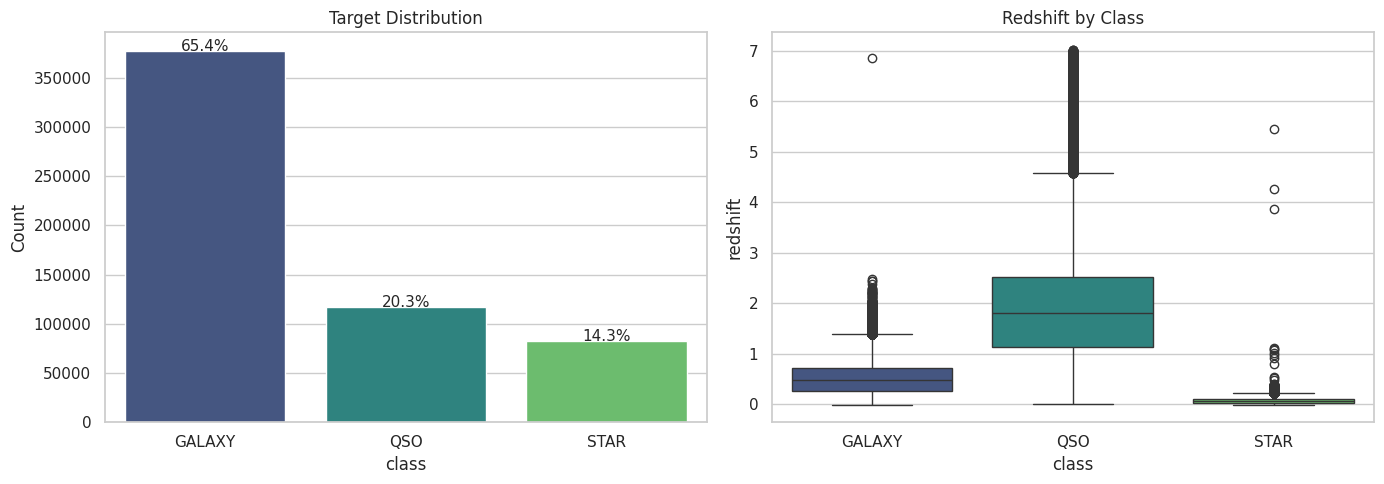

Class distribution (%):
class
GALAXY    65.38
QSO       20.29
STAR      14.33


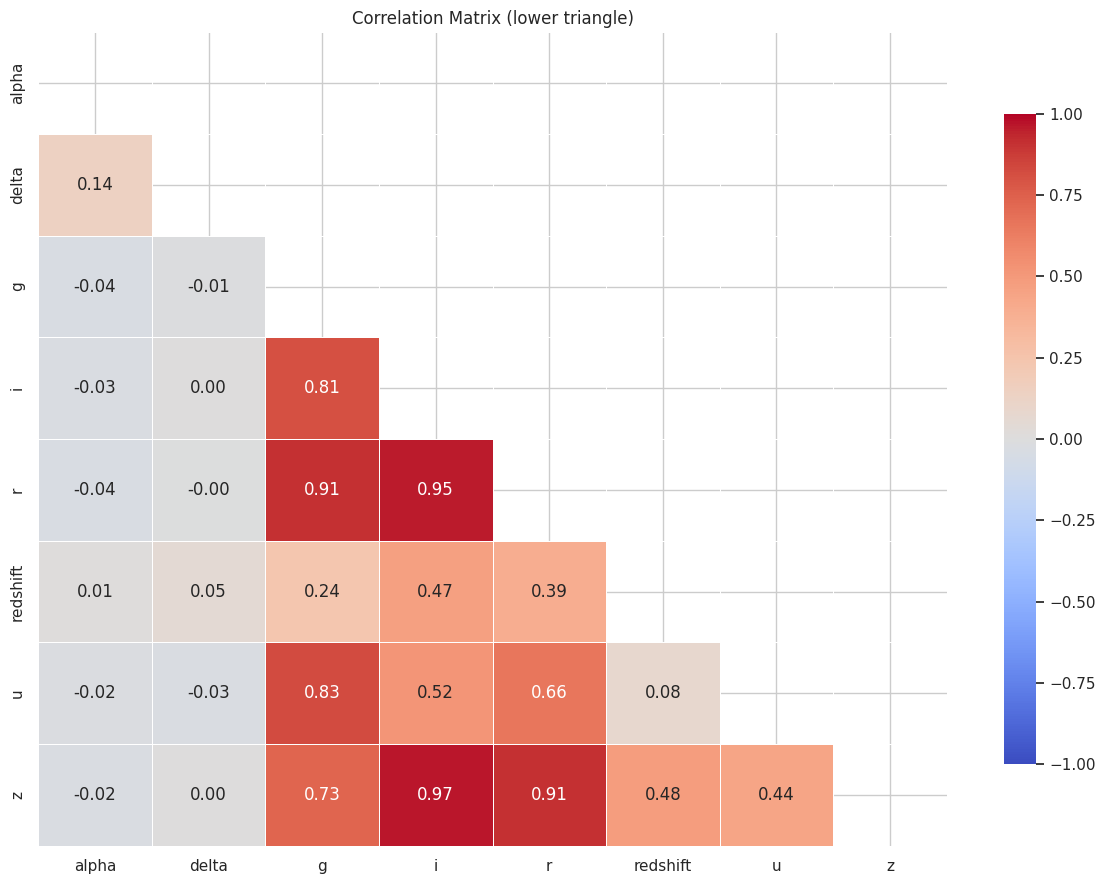

In [3]:
# ── Target distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = train_df["class"].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", ax=axes[0])
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f"{val / len(train_df):.1%}", ha="center", fontsize=11)

# ── Redshift distribution by class ───────────────────────────────────────────
sns.boxplot(data=train_df, x="class", y="redshift", palette="viridis", ax=axes[1])
axes[1].set_title("Redshift by Class")
plt.tight_layout()
plt.show()

print("Class distribution (%):")
print((class_counts / len(train_df) * 100).round(2).to_string())

# ── Correlation heatmap ───────────────────────────────────────────────────────
num_cols = train_df.select_dtypes(include=np.number).columns.difference(["id"])
plt.figure(figsize=(12, 9))
corr = train_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (lower triangle)")
plt.tight_layout()
plt.show()

# 4. Data Preprocessing & Feature Engineering
Handle missing or infinite values, create domain-agnostic and astronomical tabular features, and label encode the target.


In [4]:
BANDS = ["u", "g", "r", "i", "z"]
CAT_COLS = ["spectral_type", "galaxy_population"]


def build_features(df: pd.DataFrame, is_train: bool, artifacts: dict) -> pd.DataFrame:
    """
    Feature engineering pipeline.

    Parameters
    ----------
    df       : Raw dataframe (train or test).
    is_train : If True, fit encoders/PCA on df; otherwise use pre-fitted ones.
    artifacts: Mutable dict that stores fitted objects across train/test calls.

    Returns
    -------
    Feature matrix (no 'id', no 'class' column).
    """
    df = df.copy()

    # ── 1. Handle missing / infinite values ──────────────────────────────────
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    if is_train:
        artifacts["num_medians"] = df[BANDS + ["alpha", "delta", "redshift"]].median()
    df.fillna(artifacts["num_medians"], inplace=True)

    # ── 2. Categorical encoding ──────────────────────────────────────────────
    if is_train:
        oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        df[CAT_COLS] = oe.fit_transform(df[CAT_COLS])
        artifacts["ordinal_encoder"] = oe
    else:
        df[CAT_COLS] = artifacts["ordinal_encoder"].transform(df[CAT_COLS])

    # ── 3. Color indices ─────────────────────────────────────────────────────
    df["u-g"] = df["u"] - df["g"]
    df["g-r"] = df["g"] - df["r"]
    df["r-i"] = df["r"] - df["i"]
    df["i-z"] = df["i"] - df["z"]
    df["u-r"] = df["u"] - df["r"]
    df["u-z"] = df["u"] - df["z"]
    df["g-z"] = df["g"] - df["z"]
    df["r-z"] = df["r"] - df["z"]
    df["u-i"] = df["u"] - df["i"]
    df["ug_gr_diff"] = df["u-g"] - df["g-r"]

    # ── 4. Aggregate band statistics ─────────────────────────────────────────
    df["avg_brightness"] = df[BANDS].mean(axis=1)
    df["std_brightness"] = df[BANDS].std(axis=1)
    df["mag_range"]      = df[BANDS].max(axis=1) - df[BANDS].min(axis=1)
    # u-band excess over average (indicator of UV-bright objects like QSOs)
    df["u_excess"]       = df["u"] - df["avg_brightness"]

    # ── 5. PCA on photometric bands ──────────────────────────────────────────
    if is_train:
        pca = PCA(n_components=3, random_state=SEED)
        pca_vals = pca.fit_transform(df[BANDS])
        artifacts["pca"] = pca
        print(f"PCA explained variance: {pca.explained_variance_ratio_.round(3)}")
    else:
        pca_vals = artifacts["pca"].transform(df[BANDS])
    for k in range(pca_vals.shape[1]):
        df[f"pca_{k+1}"] = pca_vals[:, k]

    # ── 6. Cartesian sky coordinates ─────────────────────────────────────────
    a_rad = np.deg2rad(df["alpha"])
    d_rad = np.deg2rad(df["delta"])
    df["x_sky"] = np.cos(a_rad) * np.cos(d_rad)
    df["y_sky"] = np.sin(a_rad) * np.cos(d_rad)
    df["z_sky"] = np.sin(d_rad)
    # Angular distance from galactic equator (delta = 0 plane)
    df["abs_sin_delta"] = np.abs(np.sin(d_rad))

    # ── 7. Redshift interactions ─────────────────────────────────────────────
    df["redshift_ug"]  = df["redshift"] * df["u-g"]
    df["redshift_gr"]  = df["redshift"] * df["g-r"]
    df["redshift_r"]   = df["redshift"] / (df["r"] + 1e-8)

    # ── Drop non-feature columns ─────────────────────────────────────────────
    drop_cols = ["id", "class"] + [c for c in ["alpha", "delta"] if c in df.columns]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    return df


# ── Fit on train, apply to test ───────────────────────────────────────────────
artifacts: dict = {}

le = LabelEncoder()
y_train = le.fit_transform(train_df["class"])
print("Classes:", list(le.classes_))

X_train = build_features(train_df, is_train=True,  artifacts=artifacts)
X_test  = build_features(test_df,  is_train=False, artifacts=artifacts)

print(f"\nTrain features: {X_train.shape}  Test features: {X_test.shape}")
print("Feature list:", list(X_train.columns))

Classes: ['GALAXY', 'QSO', 'STAR']
PCA explained variance: [0.807 0.163 0.021]

Train features: (577347, 32)  Test features: (247435, 32)
Feature list: ['u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u-g', 'g-r', 'r-i', 'i-z', 'u-r', 'u-z', 'g-z', 'r-z', 'u-i', 'ug_gr_diff', 'avg_brightness', 'std_brightness', 'mag_range', 'u_excess', 'pca_1', 'pca_2', 'pca_3', 'x_sky', 'y_sky', 'z_sky', 'abs_sin_delta', 'redshift_ug', 'redshift_gr', 'redshift_r']


# 5. Hyperparameter Tuning with Optuna
Set up an Optuna study to find the best hyperparameters for the LightGBM model using a 5-fold Stratified K-Fold cross-validation strategy.

Starting Optuna optimisation …


  0%|          | 0/15 [00:00<?, ?it/s]


Best log-loss : 0.965150
Best params   : {'learning_rate': 0.1488162284627277, 'num_leaves': 91, 'max_depth': 6, 'min_child_samples': 96, 'feature_fraction': 0.7678121320177449, 'bagging_fraction': 0.9982635852231622, 'bagging_freq': 6, 'reg_alpha': 0.0018181939081014732, 'reg_lambda': 9.77853593271357}


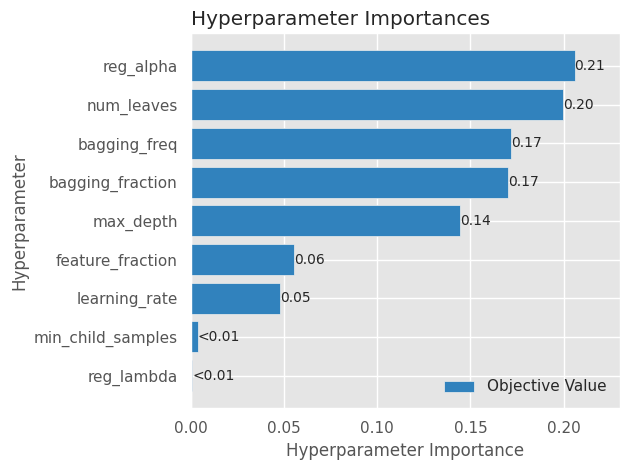

In [5]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def objective(trial: optuna.Trial) -> float:
    params = {
        "objective":        "multiclass",
        "num_class":        len(le.classes_),
        "metric":           "multi_logloss",
        "boosting_type":    "gbdt",
        "n_estimators":     TUNE_ESTIMATORS,
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":       trial.suggest_int("num_leaves", 20, 150),
        "max_depth":        trial.suggest_int("max_depth", 3, 12),
        "min_child_samples":trial.suggest_int("min_child_samples", 5, 100),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":     trial.suggest_int("bagging_freq", 1, 7),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state":     SEED,
        "verbose":          -1,
        "class_weight":     "balanced",
    }

    fold_ba = []
    for step, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, y_tr = X_train.iloc[tr_idx], y_train[tr_idx]
        X_va, y_va = X_train.iloc[va_idx], y_train[va_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
        )
        proba = model.predict_proba(X_va)
        preds = np.argmax(proba, axis=1)
        fold_ba.append(balanced_accuracy_score(y_va, preds))

        # Prune after fold 1 if clearly worse than median
        trial.report(np.mean(fold_ba), step)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_ba))


print("Starting Optuna optimisation …")
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest log-loss : {study.best_value:.6f}")
print(f"Best params   : {study.best_trial.params}")

# ── Visualise Optuna results ──────────────────────────────────────────────────
try:
    fig = optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout()
    plt.show()
except Exception:
    pass

best_params = {
    **study.best_trial.params,
    "objective":     "multiclass",
    "num_class":     len(le.classes_),
    "metric":        "multi_logloss",
    "boosting_type": "gbdt",
    "n_estimators":  FINAL_ESTIMATORS,
    "random_state":  SEED,
    "verbose":       -1,
    "class_weight":  "balanced",
}

# 6. Model Training & Evaluation
Train the model across the folds using the best hyperparameters found by Optuna, evaluate using the out-of-fold Balanced Accuracy score, and plot the feature importances.

── Fold 1/5 ──────────────────────────────────────
  Balanced Accuracy : 0.96453   Log-Loss : 0.09733
── Fold 2/5 ──────────────────────────────────────
  Balanced Accuracy : 0.96491   Log-Loss : 0.10041
── Fold 3/5 ──────────────────────────────────────
  Balanced Accuracy : 0.96318   Log-Loss : 0.10292
── Fold 4/5 ──────────────────────────────────────
  Balanced Accuracy : 0.96422   Log-Loss : 0.09942
── Fold 5/5 ──────────────────────────────────────
  Balanced Accuracy : 0.96373   Log-Loss : 0.10046
OOF  Balanced Accuracy : 0.96412  (fold mean 0.96412 ± 0.00061)
OOF  Log-Loss          : 0.10011  (fold mean 0.10011 ± 0.00181)

── Per-class Report (OOF) ─────────────────────────────────────────────
              precision    recall  f1-score   support

      GALAXY       0.99      0.97      0.98    377480
         QSO       0.96      0.97      0.96    117143
        STAR       0.89      0.96      0.92     82724

    accuracy                           0.97    577347
   macro avg     

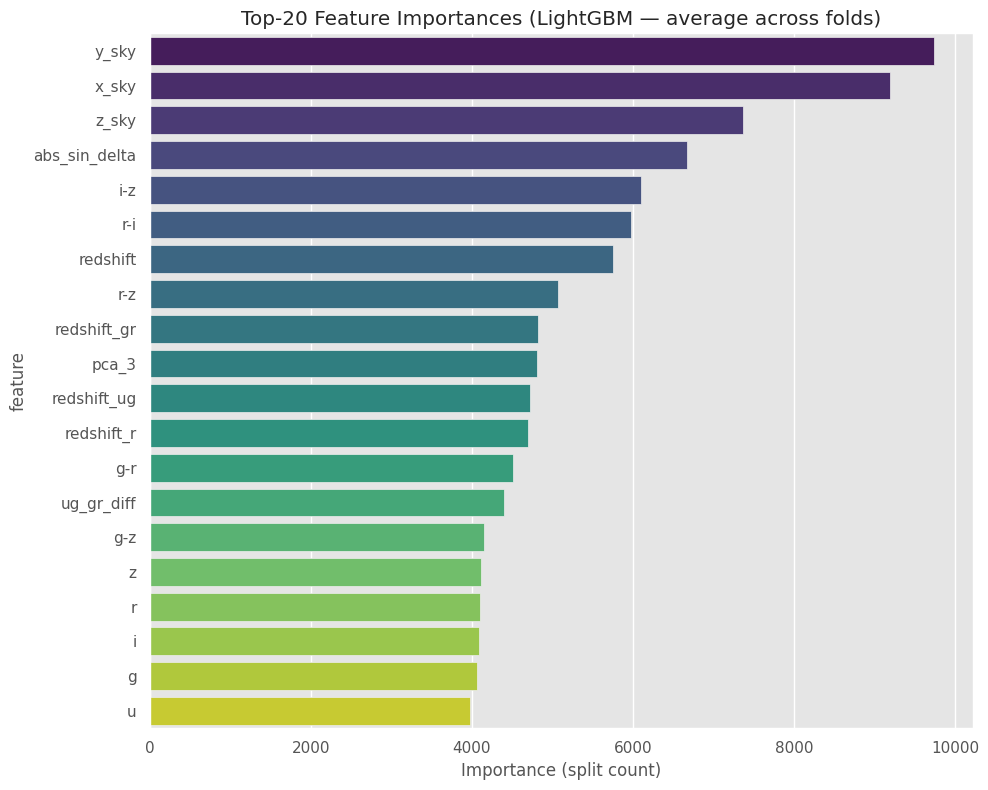

,fold,balanced_accuracy,log_loss
0,1,0.964531,0.097329
1,2,0.964914,0.100413
2,3,0.963184,0.102925
3,4,0.964221,0.099421
4,5,0.963731,0.100457


In [6]:
oof_proba  = np.zeros((len(X_train), len(le.classes_)))  # [n_samples, n_classes]
test_proba = np.zeros((len(X_test),  len(le.classes_)))
feat_imp   = pd.DataFrame({"feature": X_train.columns})
fold_ba, fold_ll = [], []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"── Fold {fold + 1}/{N_FOLDS} ──────────────────────────────────────")

    X_tr, y_tr = X_train.iloc[tr_idx], y_train[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train[va_idx]

    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )

    proba = model.predict_proba(X_va)
    preds = np.argmax(proba, axis=1)

    ba = balanced_accuracy_score(y_va, preds)
    ll = log_loss(y_va, proba)
    fold_ba.append(ba);  fold_ll.append(ll)
    print(f"  Balanced Accuracy : {ba:.5f}   Log-Loss : {ll:.5f}")

    oof_proba[va_idx] = proba
    test_proba       += model.predict_proba(X_test) / N_FOLDS
    feat_imp[f"fold_{fold}"] = model.feature_importances_

print("=" * 60)
oof_preds = np.argmax(oof_proba, axis=1)
oof_ba    = balanced_accuracy_score(y_train, oof_preds)
oof_ll    = log_loss(y_train, oof_proba)
print(f"OOF  Balanced Accuracy : {oof_ba:.5f}  (fold mean {np.mean(fold_ba):.5f} ± {np.std(fold_ba):.5f})")
print(f"OOF  Log-Loss          : {oof_ll:.5f}  (fold mean {np.mean(fold_ll):.5f} ± {np.std(fold_ll):.5f})")

print("\n── Per-class Report (OOF) ─────────────────────────────────────────────")
print(classification_report(y_train, oof_preds, target_names=le.classes_))

# ── Feature importance plot ───────────────────────────────────────────────────
feat_imp["avg"] = feat_imp[[f"fold_{f}" for f in range(N_FOLDS)]].mean(axis=1)
top20 = feat_imp.nlargest(20, "avg")

plt.figure(figsize=(10, 8))
sns.barplot(data=top20, x="avg", y="feature", palette="viridis")
plt.title("Top-20 Feature Importances (LightGBM — average across folds)")
plt.xlabel("Importance (split count)")
plt.tight_layout()
plt.show()

# ── Fold summary ─────────────────────────────────────────────────────────────
fold_summary = pd.DataFrame({
    "fold": range(1, N_FOLDS + 1),
    "balanced_accuracy": fold_ba,
    "log_loss": fold_ll,
})
display(fold_summary)

# 7. Inference & Submission
Predict on the test set using averaged predictions from all folds, inverse-transform the predictions, and save `submission.csv`.

In [7]:
final_preds  = np.argmax(test_proba, axis=1)
final_labels = le.inverse_transform(final_preds)

submission = pd.DataFrame({
    "id":    test_df["id"],
    "class": final_labels,
})

submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Saved {len(submission):,} predictions → {submission_path}")
print("\nPrediction distribution:")
print(submission["class"].value_counts().to_string())
display(submission.head(10))

Saved 247,435 predictions → submission.csv

Prediction distribution:
class
GALAXY    158773
QSO        50868
STAR       37794


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY
